# 01 · Micrograd: Derivatives, Backprop & a Tiny Neural Net

Building an autograd engine (`Value` class) from scratch: numerical derivatives → chain rule → automatic backpropagation → neuron / layer / MLP, then cross-checked against PyTorch.

**What I learned:** how gradients flow through a computation graph, why gradients must *accumulate* when a node is reused, and how PyTorch autograd does the same thing.

*Following Andrej Karpathy's "Neural Networks: Zero to Hero" (micrograd), re-implemented with my own notes.*

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR_USERNAME/llm-from-scratch/blob/main/01-micrograd/01_micrograd_backprop.ipynb)

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
def f(x):
  return 3*x**2 - 4*x + 5

[100.      91.6875  83.75    76.1875  69.      62.1875  55.75    49.6875
  44.      38.6875  33.75    29.1875  25.      21.1875  17.75    14.6875
  12.       9.6875   7.75     6.1875   5.       4.1875   3.75     3.6875
   4.       4.6875   5.75     7.1875   9.      11.1875  13.75    16.6875
  20.      23.6875  27.75    32.1875  37.      42.1875  47.75    53.6875]


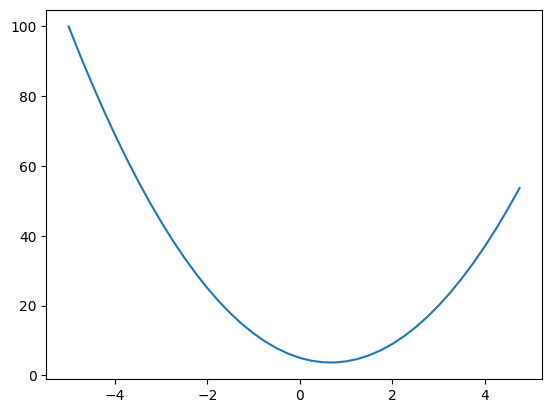

In [ ]:
xs = np.arange(-5,5,0.25)
ys = f(xs)
print(ys)
plt.plot(xs,ys)

#Derivative
##* Rise = f(x+h) - f(x)
##* Run = h
##* Slope = (f(x+h)-f(x)) / h

#Example 1 Derivative

In [ ]:
def fun():
  h = 0.001
  x = 3.0
  print(f(x))
  print(f(x+h))
  print(f"RISE :{f(x+h)-f(x)}")
  print(f"RUN :{h}")
  print(f"SLOPE :{(f(x+h)-f(x))/h}")
fun()

20.0
20.014003000000002
RISE :0.01400300000000243
RUN :0.001
SLOPE :14.00300000000243


#Example 2 Derivative

In [ ]:
def fun1():
  h = 0.001
  x =-3.0
  print(f"RISE :{f(x+h)-f(x)}")
  print(f"RUN :{h}")
  print(f"SLOPE :{(f(x+h)-f(x))/h}")
fun1()

RISE :-0.021996999999998934
RUN :0.001
SLOPE :-21.996999999998934


#let's get more complex

In [ ]:
h = 0.0001

#inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
a += h
d2 = a*b + c

slope = (d2-d1)/h
print(slope)


-3.000000000010772


In [ ]:
class Value:

  def __init__(self,data,_children=(),_op='',label=''):
    self.data = data
    self.grad = 0.0
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data = {self.data})"

  def __add__(self,other):
    out = Value(self.data + other.data, (self,other),'+')
    return out

  def __mul__(self,other):
    out = Value(self.data * other.data,(self,other),'*')
    return out

  def tanh(self):
    x = self.data

    t = ((math.exp(2*x)-1)/(math.exp(2*x)+1))
    out = Value(t, (self, ), 'tanh')
    return out

a = Value(2.0,label ='a')
b = Value(-3.0,label='b')
c = Value(10.0,label= 'c')
e =a*b; e.label = 'e'
d = e + c
d.label = 'd'
f = Value(-2.0,label='f')
L = d*f
L.label = 'L'
print(L)
print(d._prev)

Value(data = -8.0)
{Value(data = -6.0), Value(data = 10.0)}


#VISUALIZATION

In [ ]:
!pip install graphviz

In [ ]:
from graphviz import Digraph

def trace(root):
  #builds a set of all nodes and edges in a graph
  nodes, edges = set(),set()
  def build (v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child,v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format = 'svg', graph_attr = {'rankdir':'LR'}) #left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    #for any value in the graph, create a rectangulr ('record') node for it
    dot.node(name = uid, label = "{%s |data %.4f | grad:%.4f}" % (n.label,n.data,n.grad), shape = 'record')
    if n._op:
      #if this value is a result of some operation, create an op node for it
      dot.node(name= uid + n._op, label = n._op)
      #and connect this node to it
      dot.edge(uid + n._op, uid)
  for n1, n2 in edges:
    #connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)
  return dot

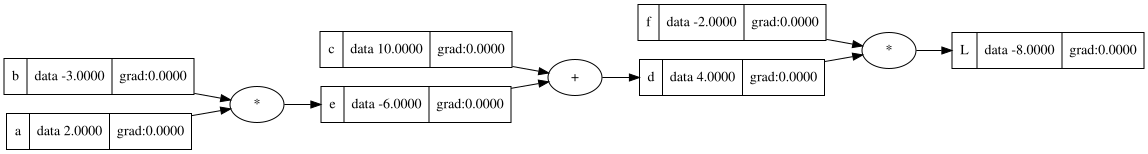

In [ ]:
draw_dot(L)

In [ ]:
L.grad = 1.0

L = d * f

dL/dd =? f

((f(x+h)-f(x))/h)

((d+h)*f - d*f)/h

(d*f + h*f -d*f) /h

(h*f)/h

f


In [ ]:
#grad of d = dl/dd
d.grad = -2.0000

L = d*f

dL/df = ?d

(f(x+h)-f(x))/h

((f+h)d-fd)/h

(fd + hd - fd)/h

hd / h

d

In [ ]:
#grad of f = dl/df
f.grad =  4.0000

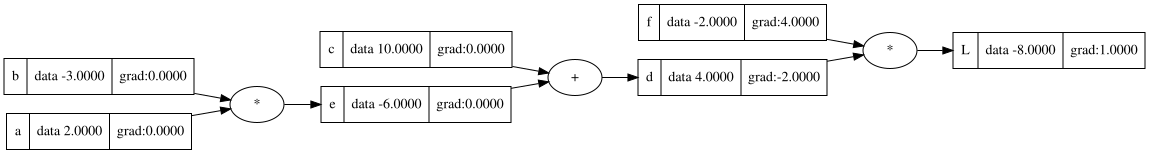

In [ ]:
draw_dot(L)

# Chain Rule to

#### **WANT**:
#### dL/dc ?

#### **KNOW**:
#### dL / dd
#### dd / dc


## dL/dc = (dL/dd) . (dd/dc)




#####grad of c = dL/dc

#####dL/dc ? -2

##### dL/dc = dL/dd * dd/dc

##### dL/dd ? -2

##### dd/dc ? 1

In [ ]:
# grad of c = dL/dc

c.grad = -2.0000 * 1.0

In [ ]:
# grad of e = dL/de

# dL/de = dL/dd * dd/de

# d=e+c
# dd/de ?
# (f(x+h)-f(x))/h
# (((e+h)+c)-(e+c))/h
# (e+h+c-e-c)/h
# h/h
# 1


e.grad = -2.0000 * 1.0

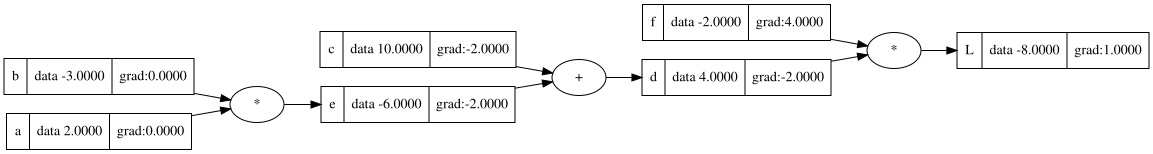

In [ ]:
draw_dot(L)

In [ ]:
#grad of a = dL/da

# dL/da = dL/de * de/da

# de/da ? b
e = a*b

# (f(x+h)-f(x))/h
# (((a+h)b) - (a*b))/h
# (a*b +h*b -a*b)/h
# (h)(b)/h
# b

# dL/da = -2.0000 * 1.0

a.grad = -2.0000 * b.data


In [ ]:
#grad of b = dL/db

# dL/db = dL/de * de/db

# de/db ? a
# e = a*b

# (f(x+h)-f(x))/h
# (a(b+h)-a*b)/h
# (a*b +h*a -a*b)h

# h*a/h
# a


b.grad = -2.0000 * a.data

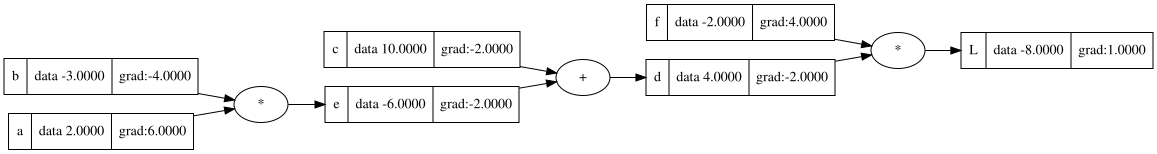

In [ ]:
draw_dot(L)

In [ ]:
def lol():

  h = 0.001

  a = Value(2.0,label ='a')
  b = Value(-3.0,label='b')
  c = Value(10.0,label= 'c')
  e =a*b; e.label = 'e'
  d = e + c
  d.label = 'd'
  f = Value(-2.0,label='f')
  L = d*f
  L.label = 'L'
  L1 = L.data

  a = Value(2.0,label ='a')
  # a.data += h
  b = Value(-3.0,label='b')
  # b.data += h
  c = Value(10.0,label= 'c')
  # c.data += h
  e =a*b; e.label = 'e'
  d = e + c
  d.label = 'd'
  f = Value(-2.0,label='f')
  L = d*f; L.label = 'L'
  L2 = L.data

  print(f"{(L2-L1)/h}")


lol()


0.0


#manually gradient calculation for single neuron


###key areas
###

*   how weights will update
*   what make  backprops great





In [ ]:
#inputs x1,x2
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')

#weights w1,w2
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')

#bias of the neuron
b = Value(6.8813735870195432, label = 'b')

#x1*w1 + x2*w2 + b

x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

o = n.tanh()
o.label = 'o'



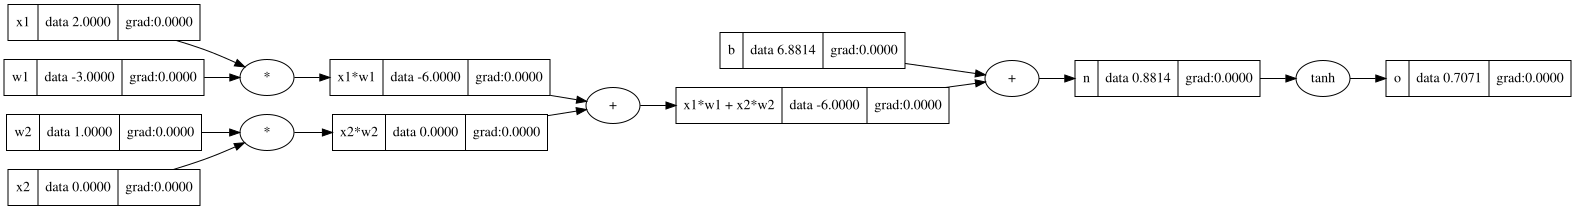

In [ ]:
draw_dot(o)

#Starting backprop from output neuron

In [ ]:
#grad of o = do/do
#do/do ? 1

o.grad = 1.0

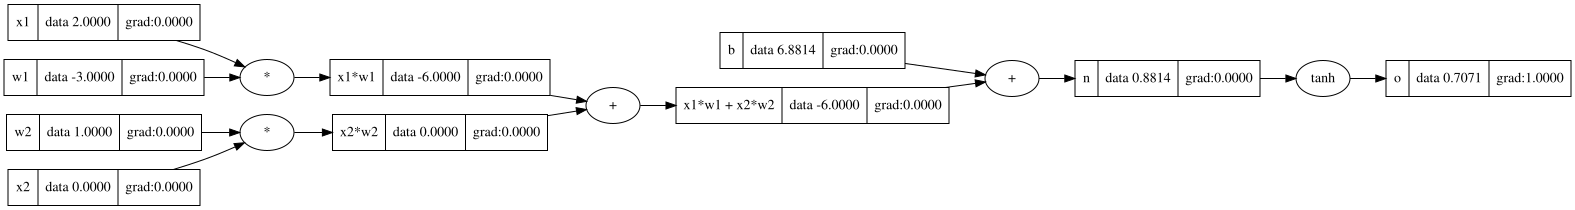

In [ ]:
draw_dot(o)

In [ ]:
1-o.data**2

0.4999999999999999

In [ ]:
#grad of n = do/dn

# o = tanh(n)

# do/dn = 1-tanh**2+n

n.grad = 1-o.data**2





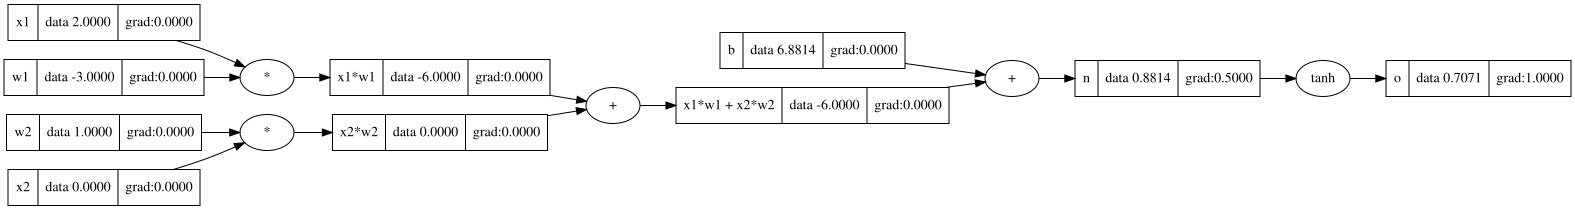

In [ ]:
draw_dot(o)

In [ ]:
# grad of b = do/db

# do/db ?

# do/db = do/dn * dn/db

# dn/db ?
# n = x1w1x2w + b

# (f(x+h)-f(x))/h
# ((x1w1x2w +(b + h)) - (x1w1x2w + b))/h

# =1


b.grad = n.grad

In [ ]:
x1w1x2w2.grad = n.grad

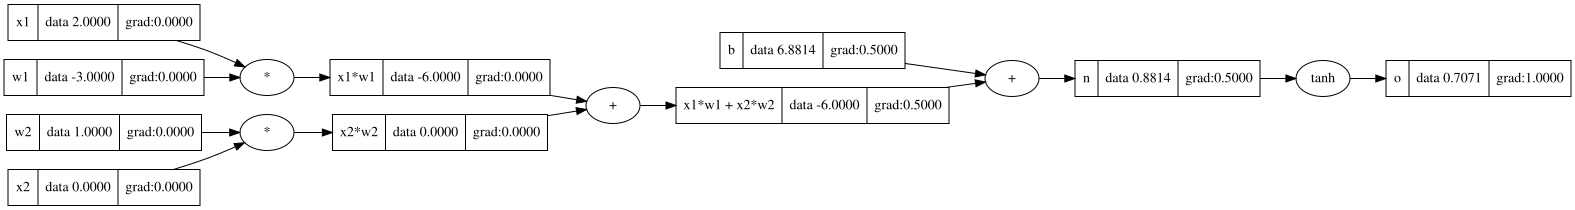

In [ ]:
draw_dot(o)

In [ ]:
x1w1.grad =  x1w1x2w2.grad
x2w2.grad = x1w1x2w2.grad

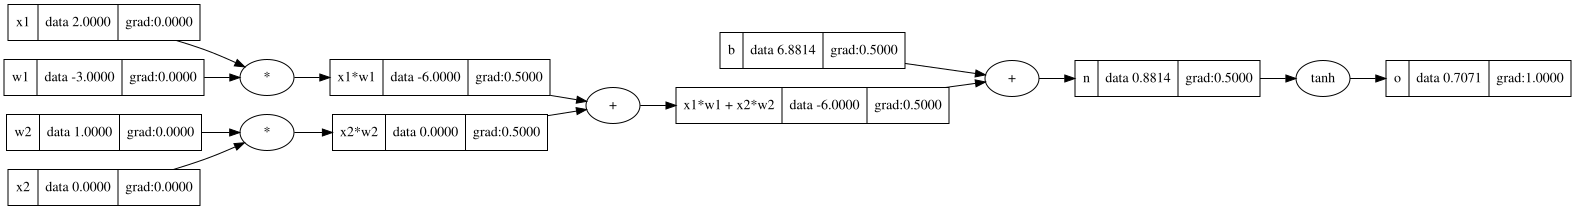

In [ ]:
draw_dot(o)

In [ ]:
# w2 grad = do/dw2
w2.grad = x2.data * x2w2.grad

#x2 grad = do/dx2
x2.grad = w2.data * x2w2.grad


#x1 grad = do/dx1
x1.grad =  w1.data  * x1w1.grad

#w1 grad = do/dw1
w1.grad = x1.data * x1w1.grad

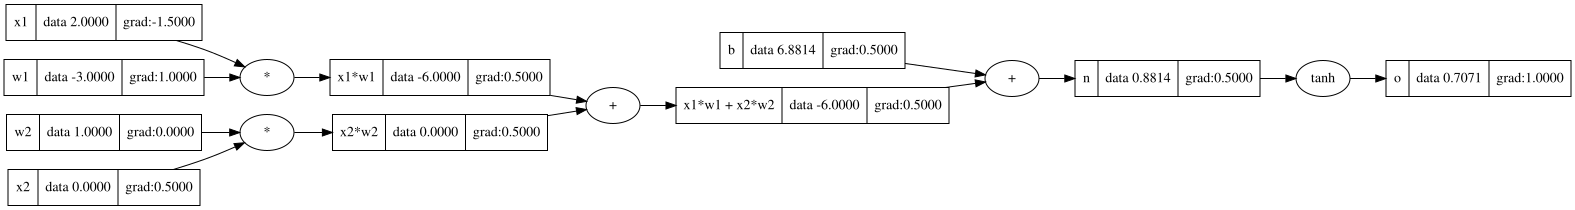

In [ ]:
draw_dot(o)

#Automate grad calculation(*BackProp*)

> "It is the basic engine that makes deep learning work."



#### implementation of backprop

In [ ]:
class Value:

  def __init__(self,data,_children=(),_op='',label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data = {self.data})"

  def __add__(self,other):
    out = Value(self.data + other.data, (self,other),'+')
    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward
    return out

  def __mul__(self,other):
    out = Value(self.data * other.data,(self,other),'*')
    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward
    return out

  def tanh(self):
    x = self.data

    t = ((math.exp(2*x)-1)/(math.exp(2*x)+1))
    out = Value(t, (self, ), 'tanh')
    def _backward():
      self.grad += (1-t**2) * out.grad
    out._backward = _backward
    return out



In [ ]:
#inputs x1,x2
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')

#weights w1,w2
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')

#bias of the neuron
b = Value(6.8813735870195432, label = 'b')

#x1*w1 + x2*w2 + b

x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

o = n.tanh()
o.label = 'o'


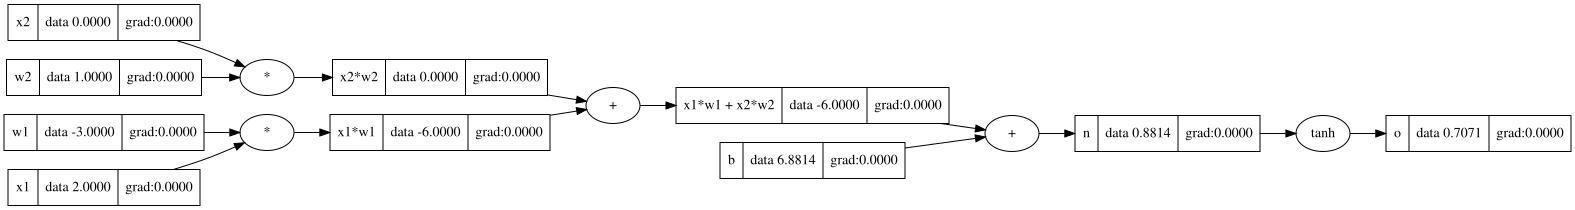

In [ ]:
draw_dot(o)

In [ ]:
o.grad = 1

In [ ]:
o._backward()

In [ ]:
n._backward()

In [ ]:
b._backward()

In [ ]:
x1w1x2w2._backward()

In [ ]:
x2w2._backward()

In [ ]:
x1w1._backward()

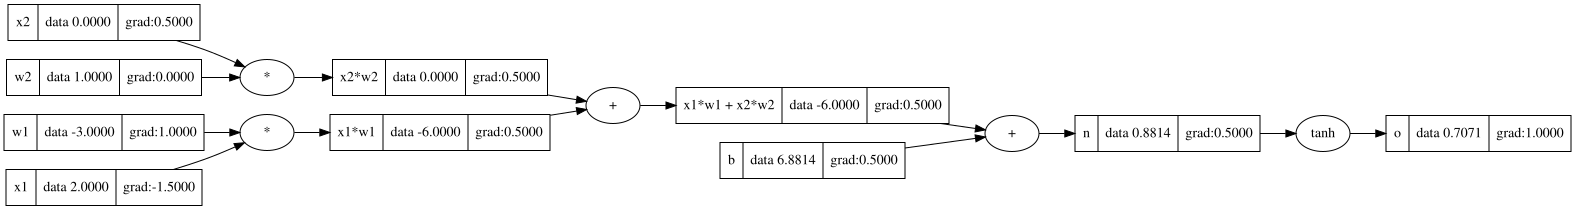

In [ ]:
draw_dot(o)

#Drawback of **current** *backprop*

##problem : "without computing a current layer going and calling further layer"

###solution : To over come this issue we are going with
#***Topological sorting***




In [ ]:
o.grad = 1.0

topo =[]
visited = set()
def build_topo(v):
  if v not in visited:
    visited.add(v)
    for child in v._prev:
      build_topo(child)
    topo.append(v)
build_topo(o)


for node in reversed(topo):
  node._backward()

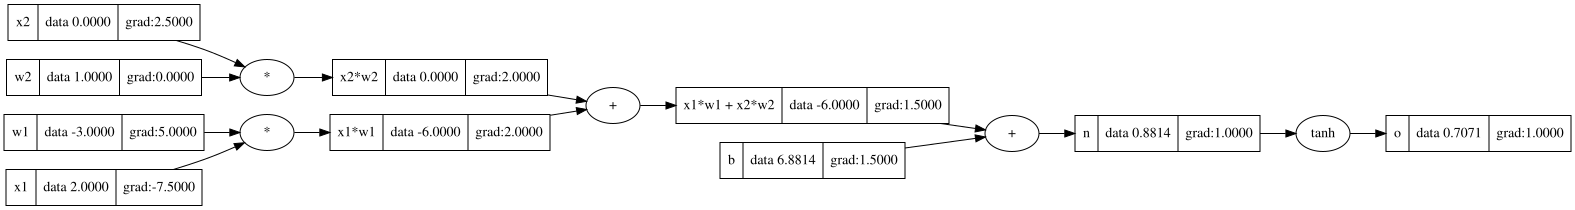

In [ ]:
draw_dot(o)

#Wrapping topologic code into backprop code  

In [ ]:
class Value:

  def __init__(self,data,_children=(),_op='',label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data = {self.data})"

  def __add__(self,other):
    out = Value(self.data + other.data, (self,other),'+')
    def _backward():
      self.grad = 1.0 * out.grad
      other.grad = 1.0 * out.grad
    out._backward = _backward
    return out

  def __mul__(self,other):
    out = Value(self.data * other.data,(self,other),'*')
    def _backward():
      self.grad = other.data * out.grad
      other.grad = self.data * out.grad
    out._backward = _backward
    return out

  def tanh(self):
    x = self.data

    t = ((math.exp(2*x)-1)/(math.exp(2*x)+1))
    out = Value(t, (self, ), 'tanh')
    def _backward():
      self.grad = (1-t**2) * out.grad
    out._backward = _backward
    return out

  def backward(self):
      topo =[]
      visited = set()
      def build_topo(v):
        if v not in visited:
          visited.add(v)
          for child in v._prev:
            build_topo(child)
          topo.append(v)
      build_topo(self)
      self.grad = 1.0
      for node in reversed(topo):
        node._backward()



In [ ]:
#inputs x1,x2
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')

#weights w1,w2
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')

#bias of the neuron
b = Value(6.8813735870195432, label = 'b')

#x1*w1 + x2*w2 + b

x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

o = n.tanh()
o.label = 'o'


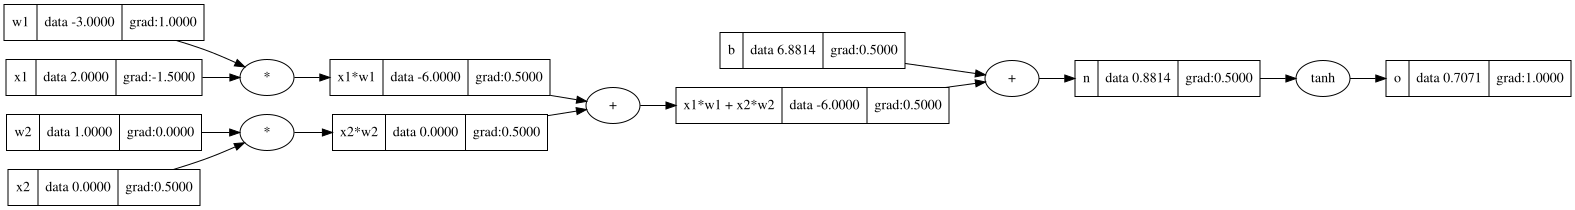

In [ ]:
o.backward()
draw_dot(o)

#Critical Bug in present code

### while using  a (same)  Value multiple time encounter incorrect gradient

### expression 1 before fix

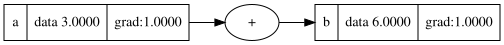

In [ ]:
a = Value(3.0,label='a')
b = a+a; b.label = 'b'
b.backward()
draw_dot(b)

### expression 2 before fix

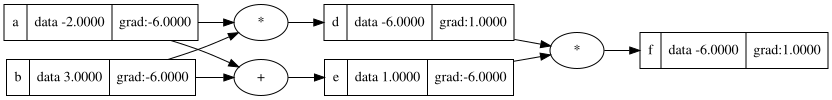

In [ ]:
#inputs

a = Value(-2.0,label='a')
b = Value(3.0,label='b')
d = a*b ; d.label='d'
e = a+b; e.label='e'
f = d*e; f.label= 'f'

f.backward()
draw_dot(f)

### fixed code

####

In [ ]:
class Value:

  def __init__(self,data,_children=(),_op='',label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data = {self.data})"

  def __add__(self,other):
    out = Value(self.data + other.data, (self,other),'+')
    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward
    return out

  def __mul__(self,other):
    out = Value(self.data * other.data,(self,other),'*')
    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward
    return out

  def tanh(self):
    x = self.data
    t = ((math.exp(2*x)-1)/(math.exp(2*x)+1))
    out = Value(t, (self, ), 'tanh')
    def _backward():
      self.grad += (1-t**2) * out.grad
    out._backward = _backward
    return out

  def backward(self):
      topo =[]
      visited = set()
      def build_topo(v):
        if v not in visited:
          visited.add(v)
          for child in v._prev:
            build_topo(child)
          topo.append(v)
      build_topo(self)
      self.grad = 1.0
      for node in reversed(topo):
        node._backward()



### expression 1 After fix

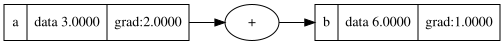

In [ ]:
a = Value(3.0,label='a')
b = a+a; b.label = 'b'
b.backward()
draw_dot(b)

### expression 2 After fix

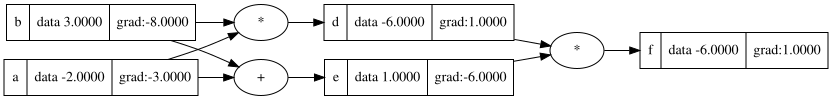

In [ ]:
a = Value(-2.0,label='a')
b = Value(3.0,label='b')
d = a*b ; d.label='d'
e = a+b; e.label='e'
f = d*e; f.label= 'f'

f.backward()
draw_dot(f)

#Adding more operators For Value class

In [ ]:
import math
class Value:

  def __init__(self,data,_children=(),_op='',label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label


  def __repr__(self):
    return f"Value(data = {self.data})"



  def __add__(self,other):
    other = other if isinstance(other,Value)else Value(other)
    out = Value(self.data + other.data, (self,other),'+')
    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward
    return out



  def __mul__(self,other):
    other = other if isinstance(other,Value)else Value(other)
    out = Value(self.data * other.data,(self,other),'*')
    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward
    return out



  def __neg__(self): #-self
    return self * -1


  def __sub__(self,other): #self - other
    return self + (-other)


  def __truediv__(self,other): #self/other
    return self * other**-1


  def __pow__(self,other):
    assert isinstance(other,(int,float)), "only supporting int/float powers for now"
    out = Value(self.data**other, (self,),f'**{other}')
    def _backward():
      self.grad += other *(self.data**(other-1))*out.grad
    out._backward = _backward
    return out


  def __rmul__(self,other):
    return self * other




  def __radd__(self,other):
    return self + other


  def __rsub__(self, other):   # other - self
    return other + (-self)



  def __rtruediv__(self, other):  # other / self
    return other * self**-1



  def exp(self):
    x = self.data
    out = Value(math.exp(x),(self,),'exp')
    def _backward():
      self.grad += out.data * out.grad
    out._backward = _backward
    return out



  def tanh(self):
    x = self.data
    t = ((math.exp(2*x)-1)/(math.exp(2*x)+1))
    out = Value(t, (self, ), 'tanh')
    def _backward():
      self.grad += (1-t**2) * out.grad
    out._backward = _backward
    return out



  def backward(self):
      topo =[]
      visited = set()
      def build_topo(v):
        if v not in visited:
          visited.add(v)
          for child in v._prev:
            build_topo(child)
          topo.append(v)
      build_topo(self)
      self.grad = 1.0
      for node in reversed(topo):
        node._backward()



In [ ]:
a = Value(2,label='a')
2*a


Value(data = 4)

In [ ]:
#inputs x1,x2
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')

#weights w1,w2
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')

#bias of the neuron
b = Value(6.8813735870195432, label = 'b')

#x1*w1 + x2*w2 + b

x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o.tanh(); o.label = 'o'
o.backward()

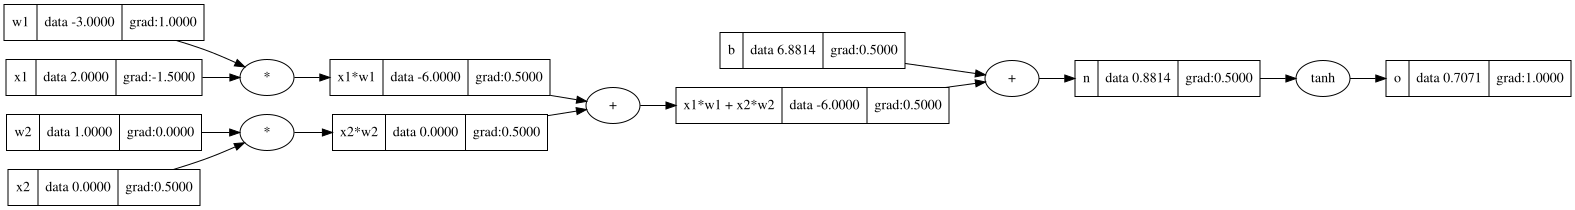

In [ ]:
draw_dot(o)

In [ ]:
#inputs x1,x2
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')

#weights w1,w2
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')

#bias of the neuron
b = Value(6.8813735870195432, label = 'b')

#x1*w1 + x2*w2 + b

x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
#-----
e = (2*n).exp()
o = (e-1)/(e+1)
o.label = 'o'
o.backward()

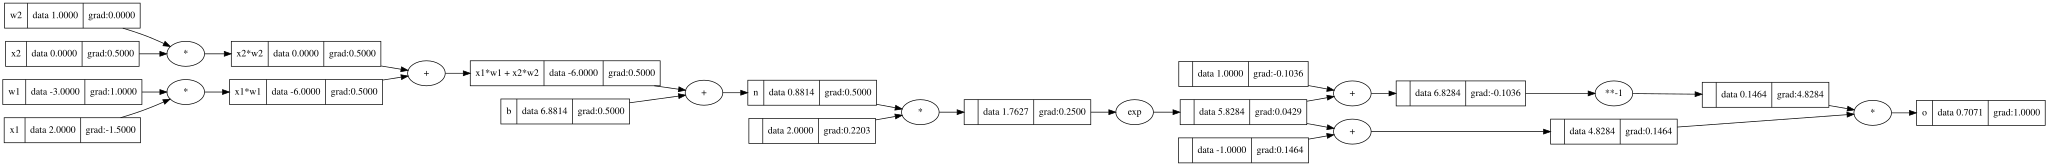

In [ ]:
draw_dot(o)

#Experimenting same idea using **pytorch**

In [ ]:
import torch

In [ ]:
x1 = torch.tensor([2.0]).double()             ; x1.requires_grad = True
x2 = torch.tensor([0.0]).double()             ; x2.requires_grad = True
w1 = torch.tensor([-3.0]).double()            ; w1.requires_grad = True
w2 = torch.tensor([1.0]).double()             ; w2.requires_grad = True
b = torch.tensor([6.8813735870195432]).double() ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)
print(o.data.item())
o.backward()
print('---')
print('x2',x2.grad.item())
print('w2',w2.grad.item())
print('x1',x1.grad.item())
print('w1',w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


# Working Multi layer perceptrons

#Neuron

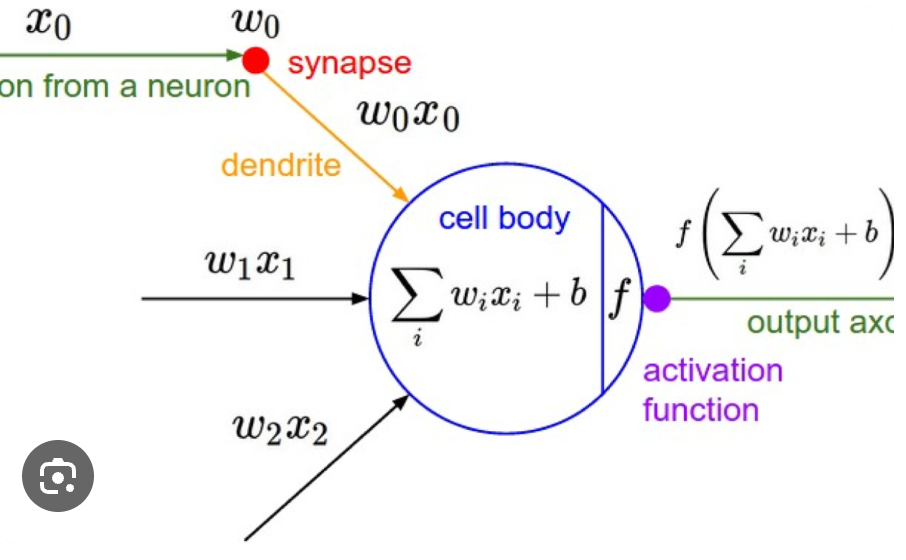

In [ ]:
import random
class Neuron:

  def __init__(self,nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))

  def __call__(self,x):
    act = sum((wi*xi for wi,xi in zip(self.w,x)),self.b)
    out = act.tanh()
    return out

  def parameters(self):
    return self.w + [self.b]


x = [2.0,3.0]
n = Neuron(2)
n(x)



Value(data = 0.05478865875292925)

#Layer


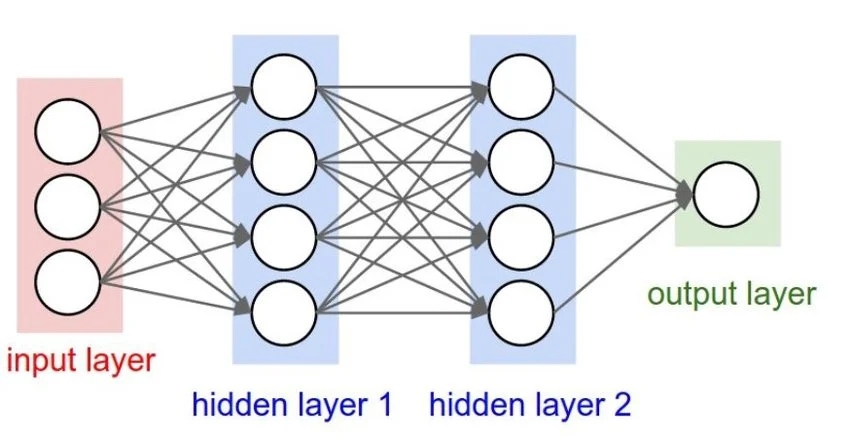

In [ ]:
class Layer:

  def __init__(self,nin,nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self,x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs

  def parameters(self):
    params = []
    for neuron in self.neurons:
      ps = neuron.parameters()
      params.extend(ps)
    return params




class MLP:

  def __init__(self,nin,nouts):
    sz = [nin]+nouts
    self.layers = [Layer(sz[i],sz[i+1]) for i in range(len(nouts))]

  def __call__(self,x):
    for layer in self.layers:
      x = layer(x)
    return x

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]


x = [2.0,3.0,-1]

n = MLP(3,[4,4,1])
n(x)




Value(data = -0.7479240966438274)

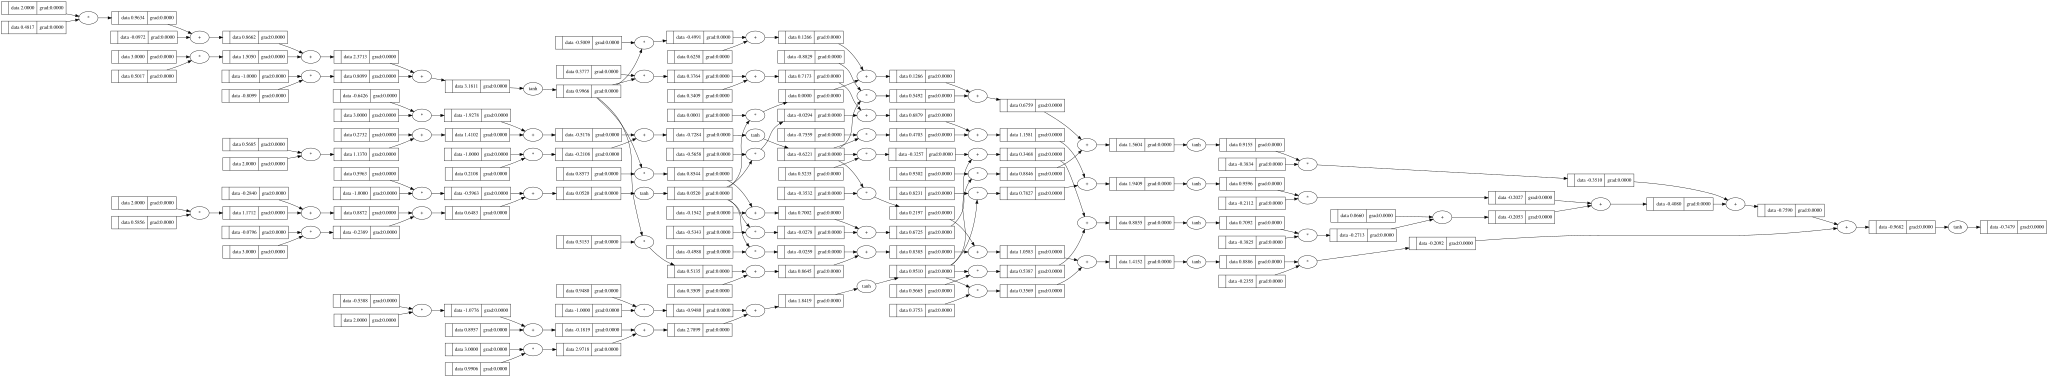

In [ ]:
draw_dot(n(x))

In [ ]:
xs_numeric = [
    [2.0,3.0,-1.0],
    [3.0,-1.0,0.5],
    [0.5,1.0,1.0],
    [1.0,1.0,-1.0]
]

# Convert numeric inputs to labeled Value objects
xs = []
for i, x_sample in enumerate(xs_numeric):
    labeled_sample = []
    for j, val in enumerate(x_sample):
        labeled_sample.append(Value(val, label=f'input_sample{i}_feature{j}'))
    xs.append(labeled_sample)

ys = [1.0,-1.0,-1.0,1.0]


In [ ]:
for k in range(150):

  #forward pass
  ypred = [n(x_sample) for x_sample in xs_numeric]


  #loss
  loss = sum((yout-ygt)**2 for ygt,yout in zip(ys,ypred))


  #backprop
  for p in n.parameters():
    p.grad = 0.0
  loss.backward()

  #update
  for p in n.parameters():
    p.data += -0.001*p.grad

  print(f'{k} step loss:{loss.data}')



0 step loss:8.845775558912132
1 step loss:8.782991637977492
2 step loss:8.718952597158548
3 step loss:8.653664158383938
4 step loss:8.58713515610914
5 step loss:8.519377726247662
6 step loss:8.450407489968933
7 step loss:8.380243729857638
8 step loss:8.308909555686716
9 step loss:8.236432056830079
10 step loss:8.162842438141588
11 step loss:8.088176135964495
12 step loss:8.012472910822046
13 step loss:7.93577691328761
14 step loss:7.858136719553455
15 step loss:7.77960533332283
16 step loss:7.700240150850593
17 step loss:7.620102886261638
18 step loss:7.539259454689109
19 step loss:7.457779811298209
20 step loss:7.375737744893607
21 step loss:7.293210625542523
22 step loss:7.210279106468894
23 step loss:7.127026781369539
24 step loss:7.043539799248334
25 step loss:6.959906439832237
26 step loss:6.8762166535929286
27 step loss:6.792561571316898
28 step loss:6.709032989010872
29 step loss:6.6257228346655115
30 step loss:6.542722623997085
31 step loss:6.460122912717921
32 step loss:6.3780

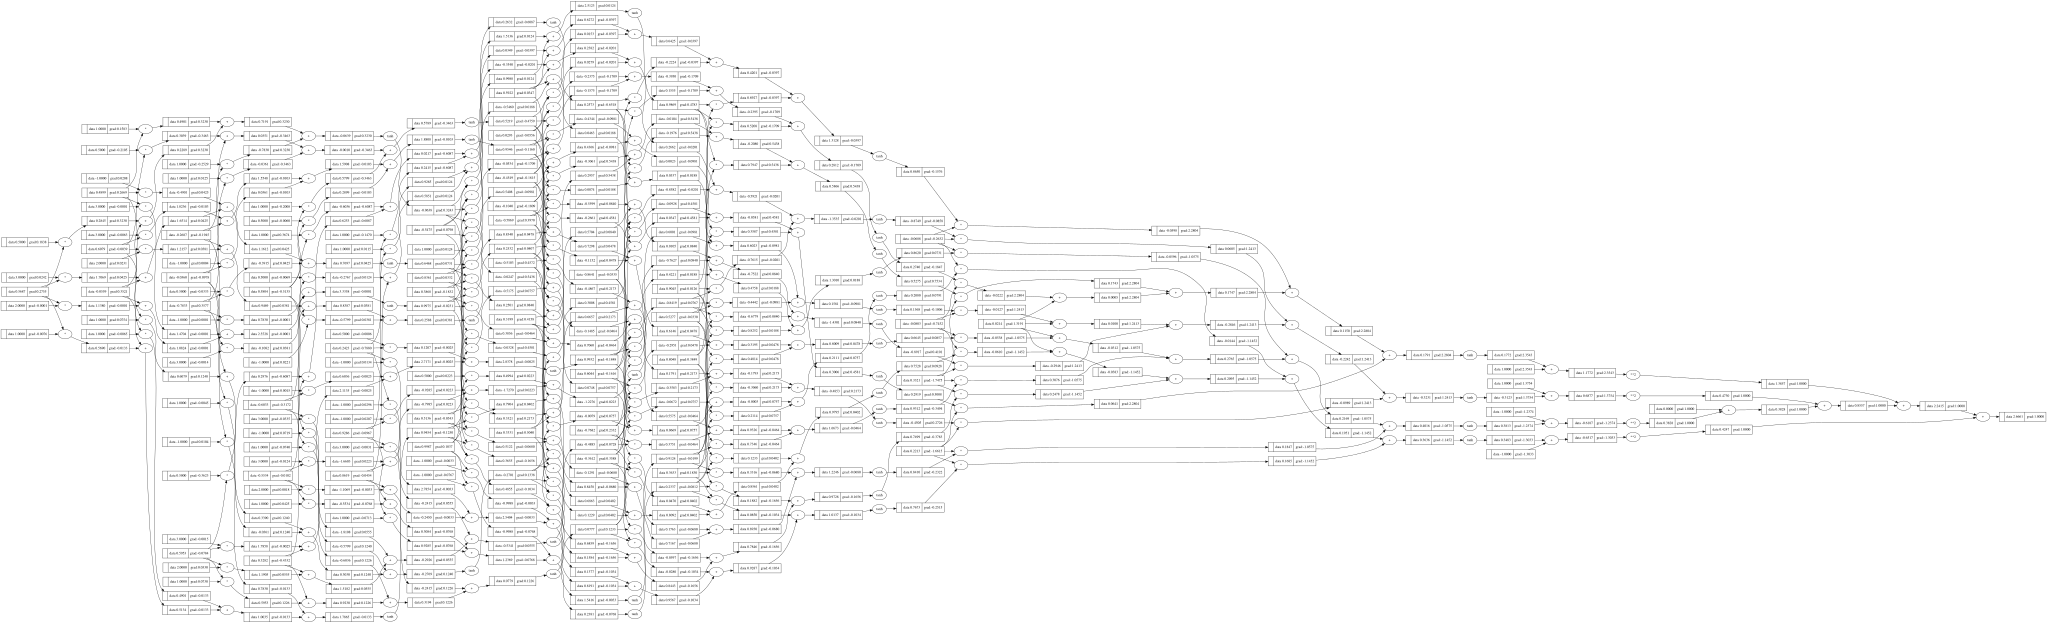

In [ ]:
draw_dot(loss)

In [ ]:
x = [2.0,3.0,-1]
n = MLP(3,[10,40,10,1])
n(x)

Value(data = 0.999027781511506)

In [ ]:
draw_dot(n(x))

In [ ]:
class Ob:

  def __init__(self,data):
    self.data =data

  def __mul__(self,other):
    other = other if isinstance(other,Ob)else Ob(other)
    return self.data*other.data

  def __rmul__(self,other):
    return self.__mul__(other)


In [ ]:
a = 5*Ob(2)

a

10